In [ ]:
!pip install matplotlib

In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os

RESULTS_DIR = "../results"
PLOTS_DIR   = "../plots"
os.makedirs(PLOTS_DIR, exist_ok=True)

In [11]:
#Load memory data
memory_df = pd.read_csv(f"{RESULTS_DIR}/memory_results.csv", index_col=0)
print(memory_df)

      allocated   reserved  memory_allocated_for_2k_generation
fp16  16.060523  16.064184                           16.581880
int8   9.095276   9.175040                            9.676418
gptq   5.745206   5.758779                            7.197649
awq    5.737473   6.803161                            6.045553


In [12]:
import glob

def load_eval(model_name):
    pattern = f"{RESULTS_DIR}/accuracy/{model_name}_eval_*.json"
    matches = glob.glob(pattern)
    if not matches:
        raise FileNotFoundError(f"No file matching {pattern}")
    with open(matches[0]) as f:
        data = json.load(f)
    r = data["results"]
    return {
        "mmlu":       r["mmlu"]["acc,none"],
        "hellaswag":  r["hellaswag"]["acc_norm,none"],
        "gsm8k":      r["gsm8k"]["exact_match,strict-match"],
        "humaneval":  r["humaneval"]["pass@1,create_test"],
        "truthfulqa": r["truthfulqa_mc1"]["acc,none"],
    }

scores = {
    "fp16": load_eval("fp16"),
    "int8": load_eval("int8"),
    "gptq": load_eval("gptq"),
    "awq":  load_eval("awq"),
}

accuracy_df = pd.DataFrame(scores).T
accuracy_df["avg_accuracy"] = accuracy_df.mean(axis=1)
print(accuracy_df[["avg_accuracy"]])

      avg_accuracy
fp16      0.636028
int8      0.638300
gptq      0.606327
awq       0.631585


In [13]:
# Build combined dataframe for Pareto chart
pareto_df = pd.DataFrame({
    "model":        memory_df.index, 
    "peak_mem_gb":  memory_df["memory_allocated_for_2k_generation"].values,
    "avg_accuracy": accuracy_df["avg_accuracy"].values,
})
print(pareto_df)

  model  peak_mem_gb  avg_accuracy
0  fp16    16.581880      0.636028
1  int8     9.676418      0.638300
2  gptq     7.197649      0.606327
3   awq     6.045553      0.631585


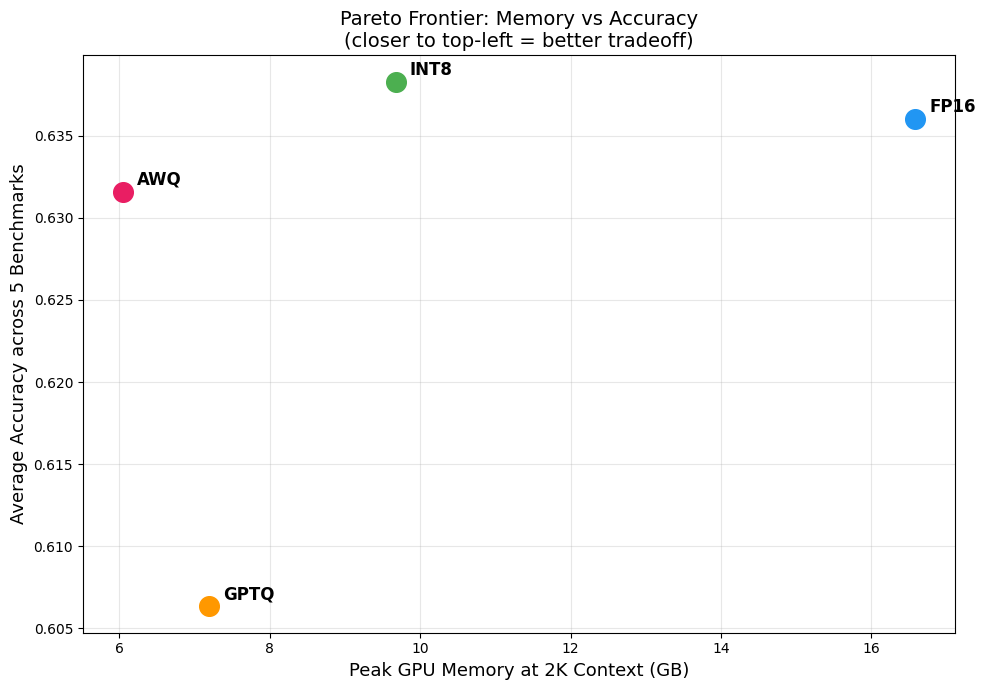

Saved pareto_memory_vs_accuracy.png — this is your headline chart


In [14]:
# Pareto scatter plot
# X = memory, Y = accuracy
# Ideal point = bottom left (low memory, high accuracy)
colors = {"fp16": "#2196F3", "int8": "#4CAF50", "gptq": "#FF9800", "awq": "#E91E63"}

fig, ax = plt.subplots(figsize=(10, 7))

for _, row in pareto_df.iterrows():
    ax.scatter(
        row["peak_mem_gb"],
        row["avg_accuracy"],
        color=colors.get(row["model"], "gray"),
        s=200,
        zorder=5
    )
    ax.annotate(
        row["model"].upper(),
        (row["peak_mem_gb"], row["avg_accuracy"]),
        textcoords="offset points",
        xytext=(10, 5),
        fontsize=12,
        fontweight="bold"
    )

ax.set_xlabel("Peak GPU Memory at 2K Context (GB)", fontsize=13)
ax.set_ylabel("Average Accuracy across 5 Benchmarks", fontsize=13)
ax.set_title("Pareto Frontier: Memory vs Accuracy\n(closer to top-left = better tradeoff)",
             fontsize=14)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/pareto_memory_vs_accuracy.png", dpi=150)
plt.show()
print("Saved pareto_memory_vs_accuracy.png — this is your headline chart")

In [15]:
# Decision matrix
# The "when would I use what" summary table
decision_matrix = pd.DataFrame([
    {
        "Constraint":      "Memory is critical (consumer GPU)",
        "Recommendation":  "GPTQ or AWQ 4-bit",
        "Why":             "4x smaller than FP16"
    },
    {
        "Constraint":      "Accuracy is paramount",
        "Recommendation":  "FP16 or INT8",
        "Why":             "Minimal precision loss"
    },
    {
        "Constraint":      "Throughput at scale",
        "Recommendation":  "AWQ",
        "Why":             "Best optimized inference kernels"
    },
    {
        "Constraint":      "Math or code heavy workload",
        "Recommendation":  "INT8 or FP16",
        "Why":             "4-bit degrades reasoning tasks"
    },
    {
        "Constraint":      "Quick experiment, no calibration",
        "Recommendation":  "bitsandbytes INT8",
        "Why":             "Zero config, just load_in_8bit=True"
    },
])

print("\nDecision Matrix — When to use what:")
print(decision_matrix.to_string(index=False))


Decision Matrix — When to use what:
                       Constraint    Recommendation                                 Why
Memory is critical (consumer GPU) GPTQ or AWQ 4-bit                4x smaller than FP16
            Accuracy is paramount      FP16 or INT8              Minimal precision loss
              Throughput at scale               AWQ    Best optimized inference kernels
      Math or code heavy workload      INT8 or FP16      4-bit degrades reasoning tasks
 Quick experiment, no calibration bitsandbytes INT8 Zero config, just load_in_8bit=True


In [17]:
memory_df

,allocated,reserved,memory_allocated_for_2k_generation
fp16,16.060523,16.064184,16.581880
int8,9.095276,9.175040,9.676418
gptq,5.745206,5.758779,7.197649
awq,5.737473,6.803161,6.045553


In [18]:
# Summary stats
# Final numbers to put in your writeup
print("\n=== Final Summary ===")
print(f"\nMemory savings vs FP16:")
fp16_mem = memory_df.loc["fp16", "memory_allocated_for_2k_generation"]
for model in ["int8", "gptq", "awq"]:
    mem = memory_df.loc[model, "memory_allocated_for_2k_generation"]
    savings = fp16_mem / mem
    print(f"  {model}: {mem:.2f} GB ({savings:.1f}x smaller)")

print(f"\nAverage accuracy vs FP16:")
fp16_acc = accuracy_df.loc["fp16", "avg_accuracy"]
for model in ["int8", "gptq", "awq"]:
    acc = accuracy_df.loc[model, "avg_accuracy"]
    drop = (fp16_acc - acc) * 100
    print(f"  {model}: {acc:.3f} ({drop:.1f} points below FP16)")


=== Final Summary ===

Memory savings vs FP16:
  int8: 9.68 GB (1.7x smaller)
  gptq: 7.20 GB (2.3x smaller)
  awq: 6.05 GB (2.7x smaller)

Average accuracy vs FP16:
  int8: 0.638 (-0.2 points below FP16)
  gptq: 0.606 (3.0 points below FP16)
  awq: 0.632 (0.4 points below FP16)
